Kent Lin Chan

20202132

Se usó Python 3.14.2

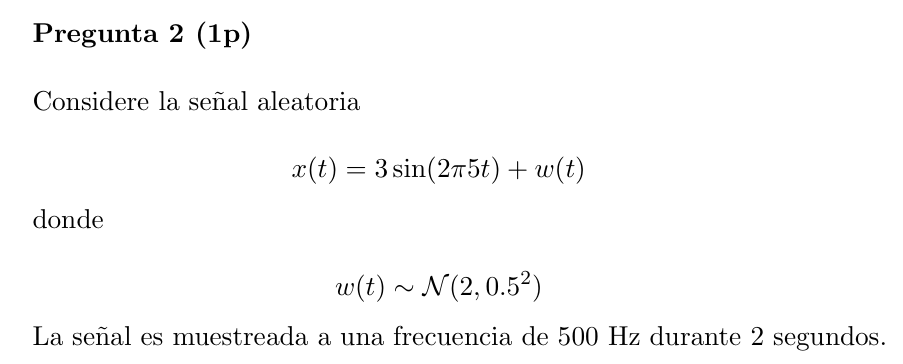

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

np.random.seed(2026)

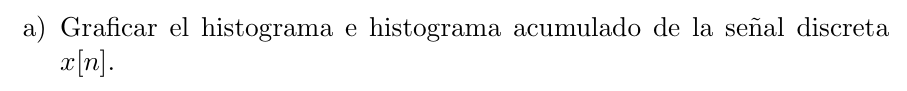

<>:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\kentj\AppData\Local\Temp\ipykernel_10440\1128042666.py:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax.set_title('Señal aleatoria $x(t) = 3\sin(2\pi \cdot 5 t) + w(t)$,  con  $w(t) \sim \mathcal{N}(2, 0.5^2)$')


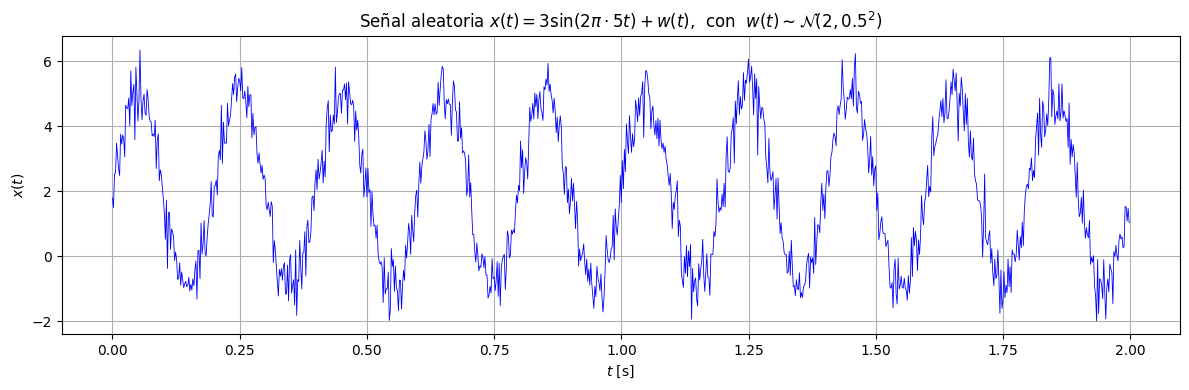

In [2]:
# Parámetros de la señal
fs = 500          # Hz, frecuencia de muestreo
T = 2             # segundos
N = int(fs * T)   # número total de muestras
t = np.arange(N) / fs

# Ruido w(t) ~ N(2, 0.5²)
mu_w = 2
sigma_w = 0.5
w = mu_w + sigma_w * np.random.randn(N)

x = 3 * np.sin(2 * np.pi * 5 * t) + w

fig, ax = plt.subplots(figsize=[12, 4])
ax.plot(t, x, 'b-', linewidth=0.6)
ax.set_xlabel('$t$ [s]')
ax.set_ylabel('$x(t)$')
ax.set_title('Señal aleatoria $x(t) = 3\sin(2\pi \cdot 5 t) + w(t)$,  con  $w(t) \sim \mathcal{N}(2, 0.5^2)$')
ax.grid(True)
plt.tight_layout()

Construimos el histograma y el histograma acumulado de la señal discreta $x[n]$

Número de muestras: N = 1000
Número de bins:     Nb = 50
Ancho de bin:       dx = 0.1905
Rango:              [np.float64(-2.4932942837685435), np.float64(6.841219112683483)]


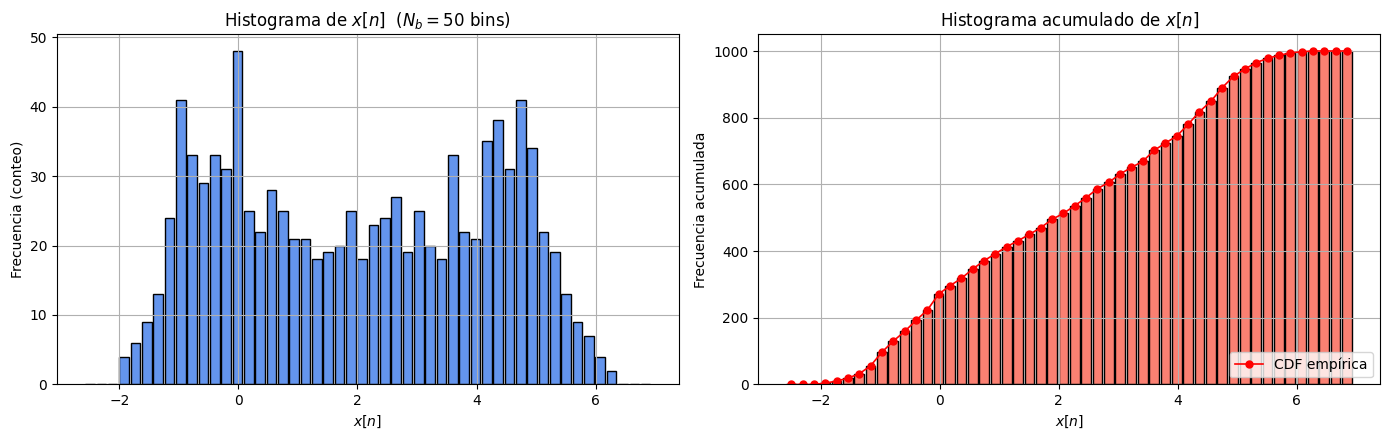

In [3]:
# Definición de bins
Nb = 50
xrange = [np.min(x) - 0.5, np.max(x) + 0.5]
dx = (xrange[1] - xrange[0]) / (Nb - 1)
bins = xrange[0] - dx/2 + np.arange(Nb + 1) * dx   # bordes
cbin = xrange[0] + np.arange(Nb) * dx              # centros

# Histograma y histograma acumulado
fig, axes = plt.subplots(1, 2, figsize=[14, 4.5])

# Histograma
h, _, _ = axes[0].hist(x, bins=bins, rwidth=0.85, align='mid', ec='k', color='cornflowerblue')
axes[0].set_xlabel('$x[n]$')
axes[0].set_ylabel('Frecuencia (conteo)')
axes[0].set_title(f'Histograma de $x[n]$  ($N_b = {Nb}$ bins)')
axes[0].grid(True)

# Histograma acumulado
h_cum, _, _ = axes[1].hist(x, bins=bins, rwidth=0.85, align='mid', cumulative=True,
                           ec='k', color='salmon')
axes[1].plot(cbin, h_cum, 'ro-', markersize=5, linewidth=1.2, label='CDF empírica')
axes[1].set_xlabel('$x[n]$')
axes[1].set_ylabel('Frecuencia acumulada')
axes[1].set_title('Histograma acumulado de $x[n]$')
axes[1].grid(True)
axes[1].legend(loc='lower right')

plt.tight_layout()

print(f"Número de muestras: N = {N}")
print(f"Número de bins:     Nb = {Nb}")
print(f"Ancho de bin:       dx = {dx:.4f}")
print(f"Rango:              {xrange}")

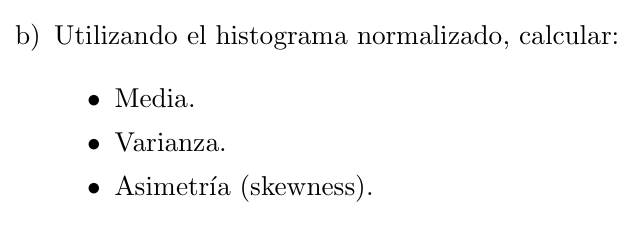

A partir del histograma normalizado (densidad de probabilidad), estimamos las estadísticas requeridas usando las siguientes expresiones:

- **Media** (esperanza): $\hat\mu_x = \sum_{k=1}^{N_b} c_k\,p_k\,\Delta x$
- **Varianza**: $\hat\sigma_x^2 = \sum_{k=1}^{N_b}(c_k - \hat\mu_x)^2\,p_k\,\Delta x$
- **Asimetría** (skewness): $\hat\gamma_x = \dfrac{1}{\hat\sigma_x^3}\sum_{k=1}^{N_b}(c_k - \hat\mu_x)^3\,p_k\,\Delta x$

In [4]:
# Densidad de probabilidad normalizada
p = h / (N * dx)   # p[k] = h[k] / (N * dx)

# Media estimada desde el histograma
mu_x_hist = np.sum(cbin * p * dx)

# Segundo momento central
x2 = np.sum(cbin**2 * p * dx)

# Varianza estimada
var_x_hist = x2 - mu_x_hist**2
sigma_x_hist = np.sqrt(var_x_hist)

# Tercer momento central
x3 = np.sum((cbin - mu_x_hist)**3 * p * dx)

# Asimetría estimada
skew_x_hist = x3 / (sigma_x_hist**3)

mu_x_theo = 0.0 + 2.0
var_x_theo = 4.5 + 0.25
skew_x_theo = 0.0

print("Estadísticas estimadas desde el histograma normalizado:")
print("-" * 70)
print(f"{'Estadística':<15} | {'Histograma':>14} | {'Teórico':>14} | {'Error abs.':>12}")
print("-" * 70)
print(f"{'Media':<15} | {mu_x_hist:>14.4f} | {mu_x_theo:>14.4f} | {abs(mu_x_hist-mu_x_theo):>12.4f}")
print(f"{'Varianza':<15} | {var_x_hist:>14.4f} | {var_x_theo:>14.4f} | {abs(var_x_hist-var_x_theo):>12.4f}")
print(f"{'Asimetría':<15} | {skew_x_hist:>14.4f} | {skew_x_theo:>14.4f} | {abs(skew_x_hist-skew_x_theo):>12.4f}")

Estadísticas estimadas desde el histograma normalizado:
----------------------------------------------------------------------
Estadística     |     Histograma |        Teórico |   Error abs.
----------------------------------------------------------------------
Media           |         2.0353 |         2.0000 |       0.0353
Varianza        |         4.7447 |         4.7500 |       0.0053
Asimetría       |         0.0266 |         0.0000 |       0.0266


<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:8: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:8: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:8: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:8: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
C:\Users\kentj\AppData\Local\Temp\ipykernel_10440\3108197924.py:8: SyntaxWarning: 

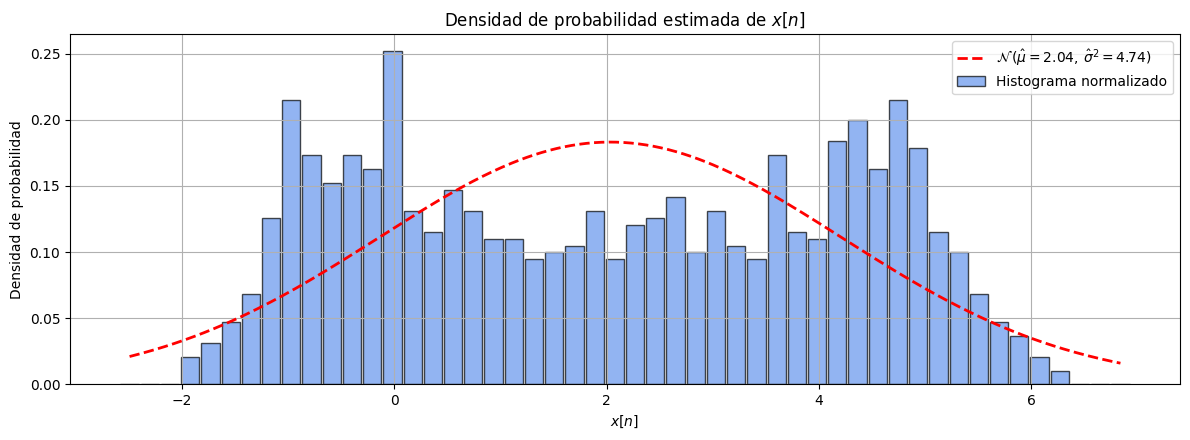

In [5]:
xx = np.linspace(xrange[0], xrange[1], 400)
pdf_gauss = (1.0 / (sigma_x_hist * np.sqrt(2*np.pi))) * np.exp(-(xx - mu_x_hist)**2 / (2*sigma_x_hist**2))

fig, ax = plt.subplots(figsize=[12, 4.5])
# Histograma normalizado (densidad)
ax.bar(cbin, p, width=dx*0.9, ec='k', color='cornflowerblue', alpha=0.7, label='Histograma normalizado')
# Gaussiana ajustada a los momentos empíricos
ax.plot(xx, pdf_gauss, 'r--', linewidth=2, label=f'$\mathcal{{N}}\,(\hat\mu={mu_x_hist:.2f},\,\hat\sigma^2={var_x_hist:.2f})$')
ax.set_xlabel('$x[n]$')
ax.set_ylabel('Densidad de probabilidad')
ax.set_title('Densidad de probabilidad estimada de $x[n]$')
ax.grid(True)
ax.legend(loc='upper right')
plt.tight_layout()

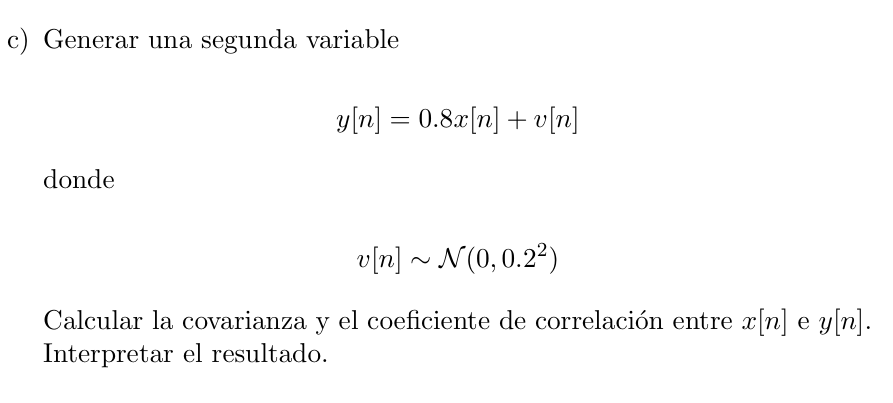

<>:17: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:17: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
C:\Users\kentj\AppData\Local\Temp\ipykernel_10440\1465764193.py:17: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
  axes[1].set_title('Señal $y[n] = 0.8\,x[n] + v[n]$,  $v[n] \sim \mathcal{N}(0, 0.2^2)$')


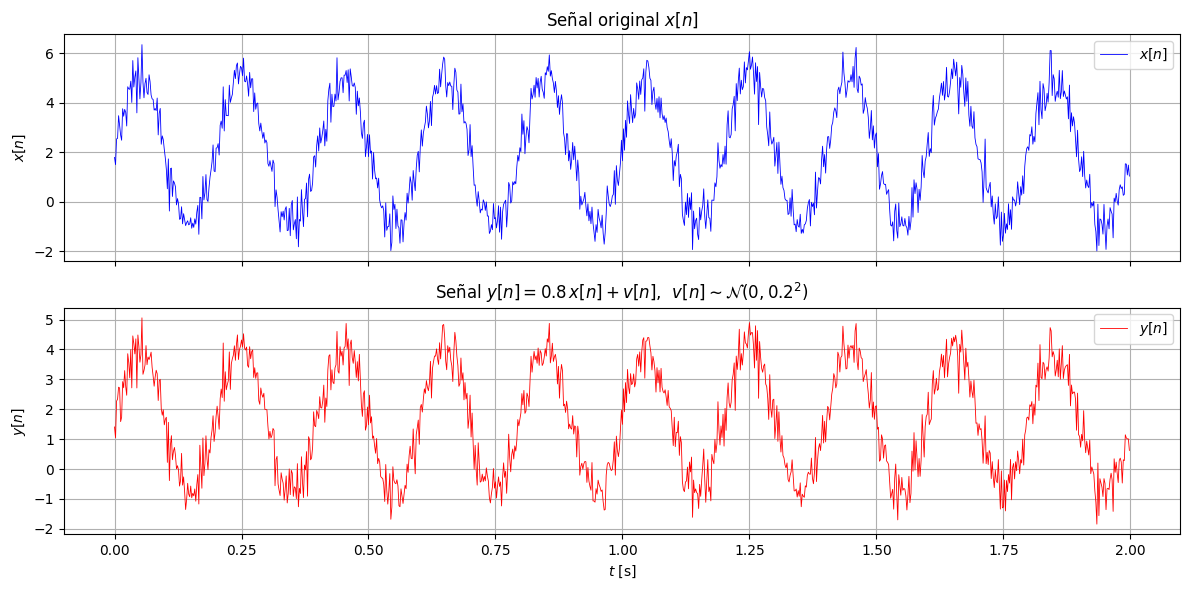

In [6]:
sigma_v = 0.2
v = sigma_v * np.random.randn(N)
y = 0.8 * x + v

# Gráfico de ambas señales
fig, axes = plt.subplots(2, 1, figsize=[12, 6], sharex=True)

axes[0].plot(t, x, 'b-', linewidth=0.6, label='$x[n]$')
axes[0].set_ylabel('$x[n]$')
axes[0].set_title('Señal original $x[n]$')
axes[0].grid(True)
axes[0].legend(loc='upper right')

axes[1].plot(t, y, 'r-', linewidth=0.6, label='$y[n]$')
axes[1].set_xlabel('$t$ [s]')
axes[1].set_ylabel('$y[n]$')
axes[1].set_title('Señal $y[n] = 0.8\,x[n] + v[n]$,  $v[n] \sim \mathcal{N}(0, 0.2^2)$')
axes[1].grid(True)
axes[1].legend(loc='upper right')

plt.tight_layout()

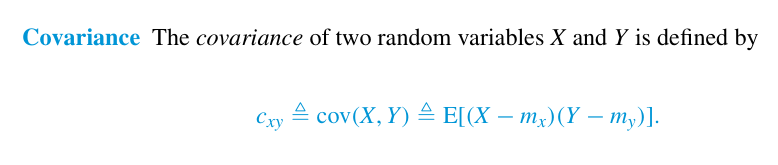

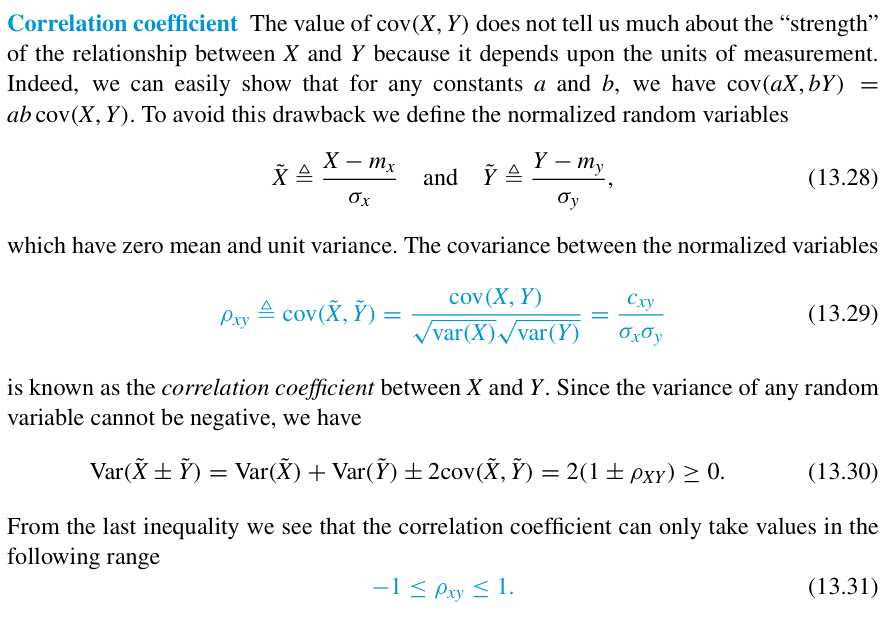

In [9]:
# Cálculo de estadísticas de x[n] e y[n]
mu_x = np.mean(x)
mu_y = np.mean(y)
sigma_x = np.std(x, ddof=0)
sigma_y = np.std(y, ddof=0)

# Covarianza muestral
cov_xy = np.mean((x - mu_x) * (y - mu_y))

# Coeficiente de correlación de Pearson
rho_xy = cov_xy / (sigma_x * sigma_y)

# Verificación con numpy
cov_np = np.cov(x, y, ddof=0)[0, 1]
rho_np = np.corrcoef(x, y)[0, 1]

print("Estadísticas de x[n] e y[n]:")
print("-" * 70)
print(f"  E[x]      = {mu_x:.4f}      std(x) = {sigma_x:.4f}")
print(f"  E[y]      = {mu_y:.4f}      std(y) = {sigma_y:.4f}")
print()
print("Covarianza y correlación:")
print("-" * 70)
print(f"  Cov(x, y) calculada   = {cov_xy:.4f}")
print(f"  Cov(x, y) con np.cov  = {cov_np:.4f}")
print(f"  p(x, y) calculada     = {rho_xy:.4f}")
print(f"  p(x, y) con np.corrcoef = {rho_np:.4f}")

Estadísticas de x[n] e y[n]:
----------------------------------------------------------------------
  E[x]      = 2.0371      std(x) = 2.1758
  E[y]      = 1.6274      std(y) = 1.7513

Covarianza y correlación:
----------------------------------------------------------------------
  Cov(x, y) calculada   = 3.7837
  Cov(x, y) con np.cov  = 3.7837
  p(x, y) calculada     = 0.9930
  p(x, y) con np.corrcoef = 0.9930


<>:9: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:9: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
C:\Users\kentj\AppData\Local\Temp\ipykernel_10440\1967285951.py:9: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
  label='$y = 0.8\,x + \mathbb{E}[v]$')


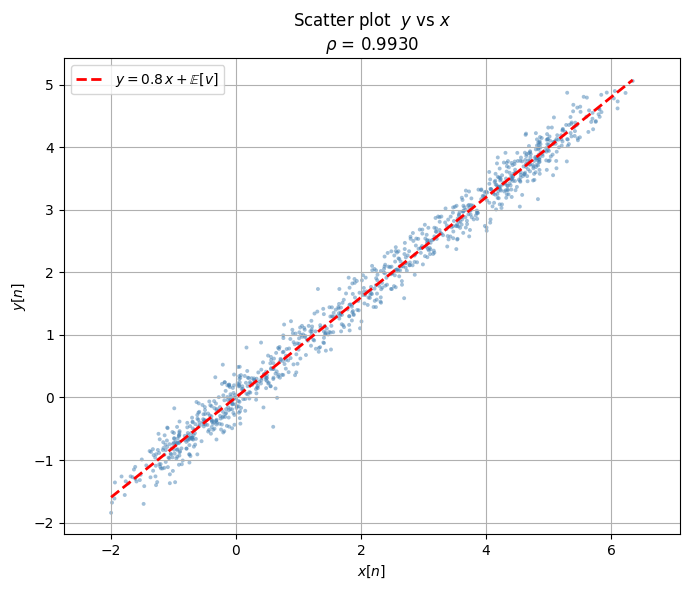

In [8]:
# Scatter plot para visualizar la relación lineal
fig, ax = plt.subplots(figsize=[7, 6])
ax.scatter(x, y, s=8, alpha=0.5, c='steelblue', edgecolor='none')

# Recta de regresión y = 0.8·x + E[v]
x_line = np.linspace(x.min(), x.max(), 100)
y_line = 0.8 * x_line + 0.0  # E[v] = 0
ax.plot(x_line, y_line, 'r--', linewidth=2,
        label='$y = 0.8\,x + \mathbb{E}[v]$')

ax.set_xlabel('$x[n]$')
ax.set_ylabel('$y[n]$')
ax.set_title('Scatter plot  $y$ vs $x$\n' + f'$\\rho$ = {rho_xy:.4f}')
ax.grid(True)
ax.legend(loc='upper left')
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()

### Interpretación de los resultados

**Covarianza $\sigma_{xy}$.** Como $y = 0.8\,x + v$ con $v$ independiente de $x$, la covarianza es:
$$\sigma_{xy} = \mathbb{E}\big[(x - \mu_x)(0.8\,x + v - \mu_y)\big] = 0.8\,\mathbb{E}[(x-\mu_x)^2] + \mathbb{E}[(x-\mu_x)]\mathbb{E}[v] = 0.8\,\sigma_x^2$$
El valor numérico coincide con la fórmula analítica.

**Coeficiente de correlación $\rho_{xy}$.** Sustituyendo:
$$\rho_{xy} = \frac{0.8\,\sigma_x^2}{\sigma_x\,\sigma_y} = \frac{0.8\,\sigma_x}{\sigma_y} = \frac{0.8\,\sigma_x}{\sqrt{0.64\,\sigma_x^2 + 0.04}}$$
Con $\sigma_x^2 = 4.75$, se obtiene $\sigma_x \approx 2.179$ y por tanto $\sigma_y \approx 1.755$, dando $\rho_{xy} \approx 0.9935$. El valor **muy cercano a 1** indica una fuerte relación lineal positiva entre $x[n]$ e $y[n]$, como era de esperarse por la construcción $y = 0.8\,x + v$ donde la mayor parte de la variabilidad de $y$ está explicada por $x$ (la varianza del ruido añadido $v$ es mucho menor que la de la parte determinística de $x$). El pequeño ruido $v$ introduce la dispersión alrededor de la recta de regresión, pero no es suficiente para destruir la correlación.